## Clustering

In [2]:
#imports
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import psycopg2
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
load_dotenv('/home/luifer/Numbersdontlie/Data-Science-Piscine/day2/ex00/.env', override=True)
import os

In [ ]:
# database connection
user = os.getenv('POSTGRES_USER')
password = os.getenv('POSTGRES_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('POSTGRES_DB')

uri = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"

In [4]:
# generate the query to get # of customers monthly
query = """
SELECT *
FROM customers
WHERE event_type = 'purchase'
ORDER BY event_time ASC;
"""

In [5]:
# generate the dataframe
with psycopg2.connect(
    user=user,
    password=password,
    host=host,
    port=port,
    dbname=dbname,
) as conn:
    df_purchase = pl.read_database(
        query,
        conn,
        infer_schema_length=10_000,
        schema_overrides={
            "product_id": pl.Int64,
            "user_id": pl.Int64,
            "price": pl.Float64,
        },
    )

### Data Agregation (RFM Feature Engineering)

We calculate 3 core customer metrics:
- Recency: Days since the customer's last purchase relative to the dataset max date
- Frequency: Number of unique order sessions
- Monetary: Total amount spent

In [7]:

# Reference date for recency calculation (latest date in dataset)
max_date = df_purchase["event_time"].max()

# 2. Aggregate RFM metrics per customer
rfm_df = (
    df_purchase.filter(pl.col("event_type") == "purchase")
    .group_by("user_id")
    .agg(
        # Recency: days since last purchase
        recency=(max_date - pl.col("event_time").max()).dt.total_days(),
        # Frequency: unique order sessions
        frequency=pl.col("user_session").n_unique(),
        # Monetary: total spending
        monetary=pl.col("price").sum(),
    )
    .filter((pl.col("frequency") > 0) & (pl.col("monetary") > 0))
)

**Scale Features and fit K-Means(k=5)**
We set k=5 clusters to create distinct groups: New Customers, Inactive Customers, Silver, Gold and Platinum Loyalty Status

In [8]:
# Log transform to reduce skewness and handle values safely
features_df = rfm_df.select(
    [
        pl.col("recency").log1p(),
        pl.col("frequency").log1p(),
        pl.col("monetary").log1p(),
    ]
)

# Convert to array and scale
X = features_df.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the DataFrame
rfm_df = rfm_df.with_columns(pl.Series("cluster", cluster_labels))

**Interpret and Map clusters to business profile**
Calculate the mean values of each cluster to assign business names to the groups

In [9]:
# Compute average RFM per cluster
cluster_summary = rfm_df.group_by("cluster").agg(
    recency_avg=pl.col("recency").mean(),
    frequency_avg=pl.col("frequency").mean(),
    monetary_avg=pl.col("monetary").mean(),
    customer_count=pl.col("user_id").count(),
).sort("monetary_avg")

print(cluster_summary)

shape: (5, 5)
┌─────────┬─────────────┬───────────────┬──────────────┬────────────────┐
│ cluster ┆ recency_avg ┆ frequency_avg ┆ monetary_avg ┆ customer_count │
│ ---     ┆ ---         ┆ ---           ┆ ---          ┆ ---            │
│ i32     ┆ f64         ┆ f64           ┆ f64          ┆ u32            │
╞═════════╪═════════════╪═══════════════╪══════════════╪════════════════╡
│ 3       ┆ 83.742896   ┆ 1.010181      ┆ 14.954372    ┆ 39976          │
│ 2       ┆ 8.829945    ┆ 1.132497      ┆ 41.174134    ┆ 13872          │
│ 0       ┆ 85.803169   ┆ 1.0           ┆ 62.876742    ┆ 35528          │
│ 4       ┆ 61.733688   ┆ 2.264517      ┆ 93.80767     ┆ 15602          │
│ 1       ┆ 20.526697   ┆ 5.18552       ┆ 267.521658   ┆ 5525           │
└─────────┴─────────────┴───────────────┴──────────────┴────────────────┘


**Mapping Logic (Assigning Business Labels based on RFM averages)

In [12]:
# Map cluster IDs to campaign target labels (adjust mappings based on cluster_summary outputs)
cluster_mapping = {
    0: "Inactive Customers",       # High recency (haven't bought in a long time)
    1: "New Customers",            # Low recency, low frequency, modest spend
    2: "Silver Loyalty",           # Moderate spend & frequency
    3: "Gold Loyalty",             # High spend & frequency
    4: "Platinum Loyalty",         # Highest spend & highest frequency
}

rfm_df = rfm_df.with_columns(
    pl.col("cluster")
    .cast(pl.Utf8)
    .replace({str(k): v for k, v in cluster_mapping.items()})
    .alias("customer_segment")
)

### 3D Scatter Plot (Recency vs Frequency vs Monetary)

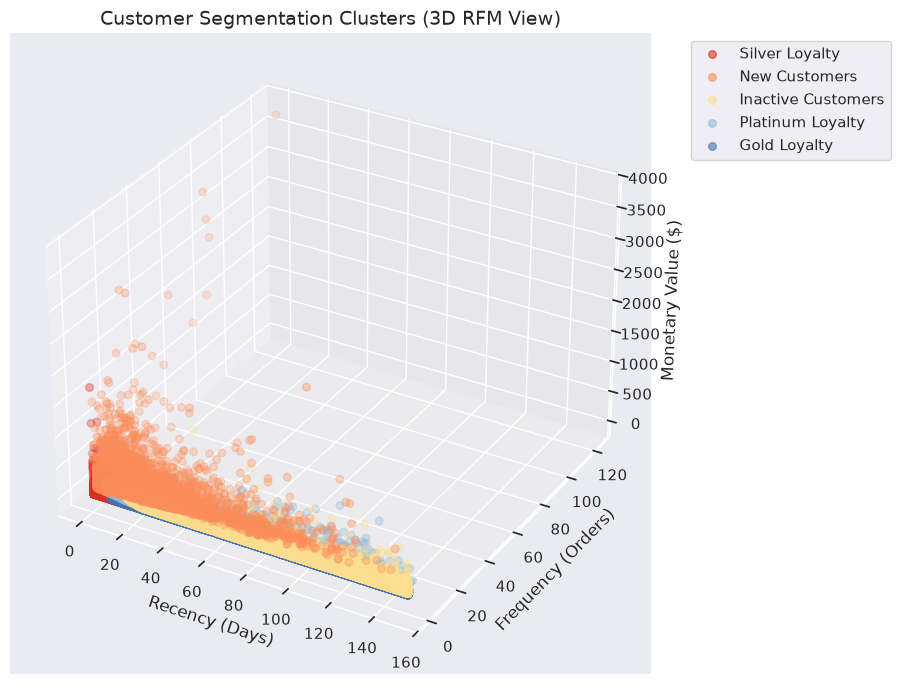

In [13]:
sns.set_theme(style="darkgrid")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot each segment
segments = rfm_df["customer_segment"].unique().to_list()
colors = ["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4"]

for segment, color in zip(segments, colors):
    sub = rfm_df.filter(pl.col("customer_segment") == segment)
    ax.scatter(
        sub["recency"],
        sub["frequency"],
        sub["monetary"],
        label=segment,
        color=color,
        alpha=0.6,
        s=30,
    )

ax.set_xlabel("Recency (Days)")
ax.set_ylabel("Frequency (Orders)")
ax.set_zlabel("Monetary Value ($)")
ax.set_title("Customer Segmentation Clusters (3D RFM View)", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Segment size and AVG spend bar plot

/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/tmp/ipykernel_267451/2936729659.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/luifer/Numbersdontlie/Data-Science-Piscine/.venv/lib/python3.15/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/tmp/ipykernel_267451/2936729659.py:27: Fu

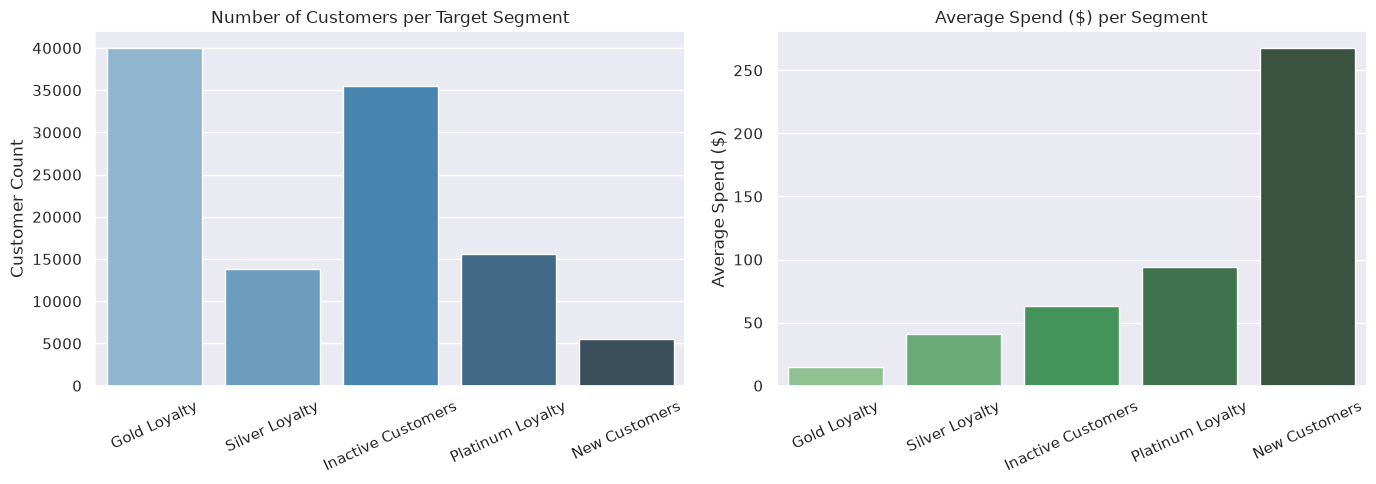

In [14]:
# Prepare aggregate metrics for plotting
segment_stats = (
    rfm_df.group_by("customer_segment")
    .agg(
        total_customers=pl.col("user_id").count(),
        avg_spend=pl.col("monetary").mean(),
    )
    .sort("avg_spend")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Customer count per segment
sns.barplot(
    data=segment_stats,
    x="customer_segment",
    y="total_customers",
    palette="Blues_d",
    ax=axes[0],
)
axes[0].set_title("Number of Customers per Target Segment", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Customer Count")
axes[0].tick_params(axis="x", rotation=25)

# Plot 2: Average monetary spend per segment
sns.barplot(
    data=segment_stats,
    x="customer_segment",
    y="avg_spend",
    palette="Greens_d",
    ax=axes[1],
)
axes[1].set_title("Average Spend ($) per Segment", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Average Spend ($)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Scatter plot clustering

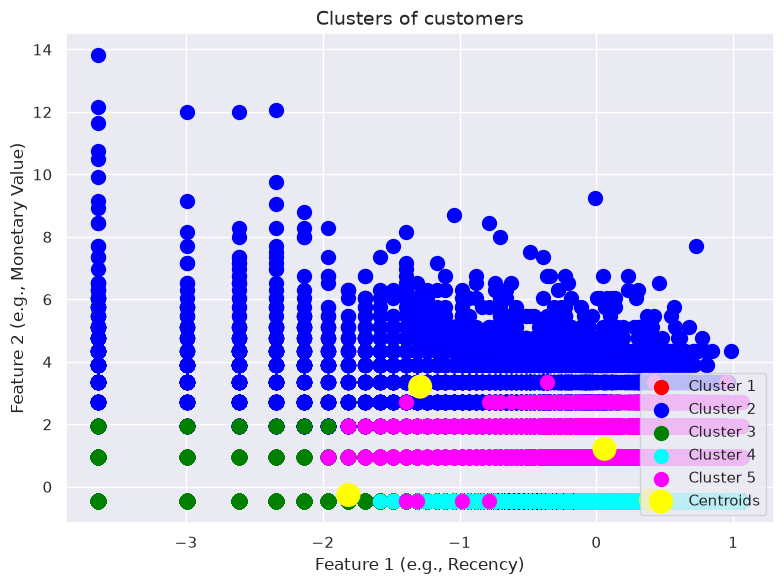

In [15]:


# 1. Apply Seaborn darkgrid theme
sns.set_theme(style="darkgrid")

# 2. Fit K-Means model (assuming 2D scaled feature array 'X_scaled')
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# 3. Get cluster centroid coordinates
centroids = kmeans.cluster_centers_

# Define specific colors matching the image
colors = ["red", "blue", "green", "cyan", "magenta"]

plt.figure(figsize=(8, 6))

# 4. Plot points for each cluster
for i in range(5):
    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        s=100,  # Scatter point size
        c=colors[i],
        label=f"Cluster {i+1}",
    )

# 5. Plot the cluster centroids (large yellow dots)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,  # Larger size for emphasis
    c="yellow",
    label="Centroids",
    edgecolor="none",
)

# 6. Customize plot details
plt.title("Clusters of customers", fontsize=14)
plt.xlabel("Feature 1 (e.g., Recency)")
plt.ylabel("Feature 2 (e.g., Monetary Value)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()